# Evaluierung & Analyse des Loss-Aggregations-Experiments (Sum vs. Mean DPO)
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert und vergleicht den Einfluss der **Sequenz-Wahrscheinlichkeits-Aggregation** im Direct Preference Optimization (DPO) Training auf das Encoder-Decoder-Modell (`facebook/mbart-large-50`):

1. **Klassische Summierung (`sum`):** $\log \pi(y \mid x) = \sum_{t=1}^T \log \pi(y_t \mid x, y_{<t})$
   * *Hypothese:* Akkumuliert negative Log-Wahrscheinlichkeiten proportional zur Textlänge. Das Modell lernt eine Kürzungsstrategie (Degeneration auf kurze Satzfragmente).
2. **Längen-normalisierter Mittelwert (`mean`):** $\overline{\log \pi(y \mid x)} = \frac{1}{T} \sum_{t=1}^T \log \pi(y_t \mid x, y_{<t})$
   * *Hypothese:* Eliminiert den Längen-Bias und bewertet die durchschnittliche Modellzuversicht pro generiertem Token, wodurch vollständige Leichte-Sprache-Sätze erhalten bleiben.

### Untersuchte Modellvarianten:
- **SFT Baseline:** Supervised Fine-Tuning Referenz (`results/models/sft`)
- **DPO Sum (Classic):** DPO-Training mit summierten Log-Likelihoods (`results/models/loss_aggregation_exp/dpo_sum`)
- **DPO Mean (Length-Normalized):** DPO-Training mit gemittelten Log-Likelihoods (`results/models/loss_aggregation_exp/dpo_mean`)

In [1]:
# ==============================================================================
# 1. SYSTEM-SETUP & IMPORTE
# ==============================================================================
import os
import sys
import json
import glob
import random
from collections import Counter
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import spacy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoConfig
from peft import PeftModel
from sentence_transformers import SentenceTransformer, util

# Arbeitsverzeichnis robust auf Projekt-Root setzen
while not (os.path.exists(".git") or os.path.exists("data")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

if not os.path.exists("data"):
    for candidate in [
        "/home/fiete/master-thesis",
        "/home/fisc4884/master-thesis",
        "/Users/fietescheel/Documents/Master Thesis",
        os.path.expanduser("~/Documents/Master Thesis"),
        os.path.expanduser("~/master-thesis")
    ]:
        if os.path.exists(candidate):
            os.chdir(candidate)
            break

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

# Seaborn & Plot Style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


In [2]:
# ==============================================================================
# 2. EXPERIMENT-KONFIGURATION & PFADE
# ==============================================================================
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_clean.json"
BASE_MODEL_NAME = "facebook/mbart-large-50"

# Simplicity Reward Model (BiLSTM Regressor)
REWARD_MODEL_PATH = "results/models/bilstm_mixup_regression.pt"
REWARD_VOCAB_PATH = "data/vocabs/mixup_vocab.json"
SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

# Zu evaluierende Modell-Pfade
MODELS_CONFIG = {
    "SFT Baseline": {
        "path": "results/models/sft",
        "color": "#7f7f7f",
        "desc": "Supervised Fine-Tuning Referenz"
    },
    "DPO Sum (Classic)": {
        "path": "results/models/loss_aggregation_exp/dpo_sum",
        "color": "#d62728",
        "desc": "Summierte Sequenz-Log-Likelihood (Kürzungs-Anfällig)"
    },
    "DPO Mean (Length-Normalized)": {
        "path": "results/models/loss_aggregation_exp/dpo_mean",
        "color": "#2ca02c",
        "desc": "Längen-normalisierter Per-Token Mean Loss"
    }
}

MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256
MAX_SAMPLES = None  # None fuer alle Saetze, oder Integer zum schnellen Testen
OUTPUT_CSV_DIR = "results/evaluation"
os.makedirs(OUTPUT_CSV_DIR, exist_ok=True)

print(f"Lebenshilfe-Testset: {LH_DATASET_PATH} (Existiert: {os.path.exists(LH_DATASET_PATH)})")
print(f"BiLSTM Reward-Modell: {REWARD_MODEL_PATH} (Existiert: {os.path.exists(REWARD_MODEL_PATH)})")
for name, cfg in MODELS_CONFIG.items():
    print(f"{name:32s} -> {cfg['path']} (Existiert: {os.path.exists(cfg['path'])})")

Lebenshilfe-Testset: data/lebenshilfe/lebenshilfe_dataset_clean.json (Existiert: True)
BiLSTM Reward-Modell: results/models/bilstm_mixup_regression.pt (Existiert: True)
SFT Baseline                     -> results/models/sft (Existiert: True)
DPO Sum (Classic)                -> results/models/loss_aggregation_exp/dpo_sum (Existiert: True)
DPO Mean (Length-Normalized)     -> results/models/loss_aggregation_exp/dpo_mean (Existiert: True)


## 2. Laden der Bewertungs-Engines (Simplicity BiLSTM & SBERT Semantik)

In [3]:
# ==============================================================================
# 3. BILSTM SIMPLICITY REGRESSOR ARCHITEKTUR & EVALUATOR
# ==============================================================================
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int = 128, hidden_dim: int = 128, dropout: float = 0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

print("Lade de_core_news_sm fuer Textverarbeitung...")
nlp = spacy.load("de_core_news_sm", disable=["ner", "tagger", "lemmatizer", "parser"])

with open(REWARD_VOCAB_PATH, "r", encoding="utf-8") as f:
    mixup_vocab = json.load(f)
print(f"MixUp Vokabular geladen: {len(mixup_vocab)} Eintraege")

simplicity_regressor = BiLSTMRegressor(vocab_size=len(mixup_vocab)).to(DEVICE)
if os.path.exists(REWARD_MODEL_PATH):
    try:
        state_dict = torch.load(REWARD_MODEL_PATH, map_location=DEVICE, weights_only=False)
    except Exception:
        state_dict = torch.load(REWARD_MODEL_PATH, map_location=DEVICE)
    if "model_state_dict" in state_dict:
        simplicity_regressor.load_state_dict(state_dict["model_state_dict"])
    else:
        simplicity_regressor.load_state_dict(state_dict)
    simplicity_regressor.eval()
    print("BiLSTM Simplicity-Modell erfolgreich geladen!")
else:
    print(f"[WARNUNG] BiLSTM Pfad '{REWARD_MODEL_PATH}' nicht gefunden.")

print(f"Lade Sentence-BERT ({SBERT_MODEL_NAME})...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, device=str(DEVICE))
print("Alle Evaluatoren erfolgreich initialisiert!")

Lade de_core_news_sm fuer Textverarbeitung...
MixUp Vokabular geladen: 19509 Eintraege
BiLSTM Simplicity-Modell erfolgreich geladen!
Lade Sentence-BERT (sentence-transformers/paraphrase-multilingual-mpnet-base-v2)...
Alle Evaluatoren erfolgreich initialisiert!


In [4]:
# ==============================================================================
# 4. HILFSFUNKTIONEN FUER METRIKBESTIMMUNG
# ==============================================================================
def text_to_tensor(texts: List[str], max_len: int = 256) -> torch.Tensor:
    batch_ids = []
    for text in texts:
        doc = nlp(text)
        ids = [mixup_vocab.get(token.text.lower(), 1) for token in doc if not token.is_space]
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [0] * (max_len - len(ids))
        batch_ids.append(ids)
    return torch.tensor(batch_ids, dtype=torch.long, device=DEVICE)

@torch.no_grad()
def compute_simplicity_scores(texts: List[str], batch_size: int = 64) -> np.ndarray:
    all_scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        tensor = text_to_tensor(batch)
        preds = simplicity_regressor(tensor).squeeze(-1).cpu().numpy()
        all_scores.extend(preds.tolist() if isinstance(preds, np.ndarray) and preds.ndim > 0 else [float(preds)])
    return np.array(all_scores)

@torch.no_grad()
def compute_semantic_similarity(texts1: List[str], texts2: List[str], batch_size: int = 64) -> np.ndarray:
    all_sims = []
    for i in range(0, len(texts1), batch_size):
        b1 = texts1[i:i+batch_size]
        b2 = texts2[i:i+batch_size]
        emb1 = sbert_model.encode(b1, convert_to_tensor=True, show_progress_bar=False)
        emb2 = sbert_model.encode(b2, convert_to_tensor=True, show_progress_bar=False)
        sims = util.cos_sim(emb1, emb2).diag().cpu().numpy()
        all_sims.extend(sims.tolist() if isinstance(sims, np.ndarray) and sims.ndim > 0 else [float(sims)])
    return np.array(all_sims)

def compute_ngram_counts(tokens: List[str], n: int) -> Counter:
    return Counter(zip(*[tokens[i:] for i in range(n)]))

def compute_sentence_bleu(ref_toks: List[str], cand_toks: List[str], max_n: int = 4) -> float:
    if len(cand_toks) == 0 or len(ref_toks) == 0:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        cand_ng = compute_ngram_counts(cand_toks, n)
        ref_ng = compute_ngram_counts(ref_toks, n)
        if sum(cand_ng.values()) == 0:
            precisions.append(0.0)
            continue
        matches = sum(min(cand_ng[ng], ref_ng[ng]) for ng in cand_ng)
        precisions.append(matches / max(1, sum(cand_ng.values())))
    if min(precisions) <= 1e-9:
        geom_mean = 0.0
    else:
        geom_mean = np.exp(np.mean([np.log(p) for p in precisions]))
    c, r = len(cand_toks), len(ref_toks)
    bp = 1.0 if c > r else np.exp(1.0 - (r / max(1, c)))
    return float(bp * geom_mean)

def compute_rouge_l(ref_toks: List[str], cand_toks: List[str]) -> float:
    if len(ref_toks) == 0 or len(cand_toks) == 0:
        return 0.0
    m, n = len(ref_toks), len(cand_toks)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m):
        for j in range(n):
            if ref_toks[i] == cand_toks[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i + 1][j], dp[i][j + 1])
    lcs = dp[m][n]
    p = lcs / max(1, n)
    r = lcs / max(1, m)
    return float(2 * p * r / max(1e-9, (p + r)))

## 3. Laden des Testdatensatzes & Inferenz

In [5]:
# ==============================================================================
# 5. INFERENZ-SCHLEIFE FUER SUM VS. MEAN DPO
# ==============================================================================
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

if MAX_SAMPLES is not None and len(lh_data) > MAX_SAMPLES:
    lh_data = lh_data[:MAX_SAMPLES]

as_texts = [item.get("source_text", item.get("as_text", item.get("source", ""))) for item in lh_data]
ls_ref_texts = [item.get("target_text", item.get("ls_text", item.get("target", ""))) for item in lh_data]

print(f"Anzahl evaluierter Lebenshilfe-Paare: {len(as_texts)}")

def load_seq2seq_model(model_path: str, base_model_name: str):
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    config = AutoConfig.from_pretrained(base_model_name)
    
    def _get_base():
        for kwargs in [
            {"use_safetensors": True},
            {"use_safetensors": False, "weights_only": False},
            {}
        ]:
            try:
                return AutoModelForSeq2SeqLM.from_pretrained(base_model_name, config=config, torch_dtype=dtype, **kwargs)
            except Exception:
                continue
        return AutoModelForSeq2SeqLM.from_pretrained(base_model_name, config=config, torch_dtype=dtype)

    if os.path.exists(os.path.join(model_path, "adapter_config.json")):
        base_m = _get_base()
        model = PeftModel.from_pretrained(base_m, model_path).to(DEVICE)
    else:
        try:
            model = AutoModelForSeq2SeqLM.from_pretrained(model_path, config=config, torch_dtype=dtype, use_safetensors=True).to(DEVICE)
        except Exception:
            model = AutoModelForSeq2SeqLM.from_pretrained(model_path, config=config, torch_dtype=dtype, weights_only=False).to(DEVICE)
    return model

valid_sentence_ends = {".", "!", "?", '."', '!"', '?"', ".'", "!'", "?'"}
all_model_results = {}
all_detailed_dfs = []

for model_name, model_info in MODELS_CONFIG.items():
    m_path = model_info["path"]
    if not os.path.exists(m_path):
        print(f"\n[UEBERSPRUNGEN] Modell '{model_name}' existiert noch nicht unter '{m_path}'.")
        continue
        
    print(f"\n{'='*70}")
    print(f"Generiere Uebersetzungen fuer: {model_name}")
    print(f"Pfad: {m_path}")
    print(f"{'='*70}")
    
    tok_path = m_path if os.path.exists(os.path.join(m_path, "tokenizer_config.json")) else BASE_MODEL_NAME
    tokenizer = AutoTokenizer.from_pretrained(tok_path, use_fast=False)
    tokenizer.src_lang = "de_DE"
    tokenizer.tgt_lang = "de_DE"
    
    model = load_seq2seq_model(m_path, BASE_MODEL_NAME)
    model.eval()
    
    gen_texts = []
    batch_size = 8
    for i in tqdm(range(0, len(as_texts), batch_size), desc=f"Inference {model_name}"):
        batch_src = as_texts[i:i+batch_size]
        inputs = tokenizer(batch_src, max_length=MAX_SOURCE_LEN, padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                max_length=MAX_TARGET_LEN,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True
            )
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        gen_texts.extend(decoded)
        
    del model
    torch.cuda.empty_cache()
    
    r_style = compute_simplicity_scores(gen_texts)
    r_sem_raw = compute_semantic_similarity(as_texts, gen_texts)
    r_sem_norm = np.clip((r_sem_raw + 1.0) / 2.0, 0.0, 1.0)
    sim_ref_raw = compute_semantic_similarity(ls_ref_texts, gen_texts)
    sim_ref_norm = np.clip((sim_ref_raw + 1.0) / 2.0, 0.0, 1.0)
    composite_reward = 0.5 * r_style + 0.5 * r_sem_norm
    
    bleu_list, rougeL_list = [], []
    src_tokens_list, gen_tokens_list = [], []
    truncation_list = []
    
    for src_s, ref_s, gen_s in zip(as_texts, ls_ref_texts, gen_texts):
        d_src = nlp(src_s)
        d_ref = nlp(ref_s)
        d_gen = nlp(gen_s)
        t_src = [t.text.lower() for t in d_src if not t.is_space]
        t_ref = [t.text.lower() for t in d_ref if not t.is_space]
        t_gen = [t.text.lower() for t in d_gen if not t.is_space]
        
        src_tokens_list.append(len(t_src))
        gen_tokens_list.append(len(t_gen))
        bleu_list.append(compute_sentence_bleu(t_ref, t_gen))
        rougeL_list.append(compute_rouge_l(t_ref, t_gen))
        
        trimmed = gen_s.strip()
        ends_clean = any(trimmed.endswith(end) for end in valid_sentence_ends) if len(trimmed) > 0 else False
        truncation_list.append(not ends_clean)
        
    comp_ratios = np.array(gen_tokens_list) / np.maximum(1, np.array(src_tokens_list))
    
    summary = {
        "Modell": model_name,
        "Ø Simplicity ($R_{style}$)": float(np.mean(r_style)),
        "Ø Semantik zu AS ($R_{sem}$)": float(np.mean(r_sem_norm)),
        "Ø Treue zu LS ($Sim_{ref}$)": float(np.mean(sim_ref_norm)),
        "Composite Reward": float(np.mean(composite_reward)),
        "BLEU": float(np.mean(bleu_list)),
        "ROUGE-L F1": float(np.mean(rougeL_list)),
        "Ø Gen. Tokens": float(np.mean(gen_tokens_list)),
        "Kompressionsrate": float(np.mean(comp_ratios)),
        "Truncation Rate (%)": float(np.mean(truncation_list) * 100)
    }
    all_model_results[model_name] = summary
    
    df_det = pd.DataFrame({
        "model_name": model_name,
        "as_text": as_texts,
        "ls_ref_text": ls_ref_texts,
        "generated_text": gen_texts,
        "r_style": r_style,
        "r_sem_as": r_sem_norm,
        "sim_ref": sim_ref_norm,
        "composite_reward": composite_reward,
        "bleu": bleu_list,
        "rouge_l": rougeL_list,
        "gen_tokens": gen_tokens_list,
        "compression_ratio": comp_ratios,
        "is_truncated": truncation_list
    })
    all_detailed_dfs.append(df_det)

if len(all_detailed_dfs) == 0 and os.path.exists("results/evaluation/loss_aggregation_comparison_summary.csv"):
    print("\n[INFO] Lade bereits bestehende Evaluationsergebnisse aus results/evaluation/...")
    df_summary = pd.read_csv("results/evaluation/loss_aggregation_comparison_summary.csv")
    df_details = pd.read_csv("results/evaluation/loss_aggregation_comparison_details.csv")
elif len(all_detailed_dfs) > 0:
    df_summary = pd.DataFrame(list(all_model_results.values()))
    df_details = pd.concat(all_detailed_dfs, ignore_index=True)
    df_summary.to_csv(os.path.join(OUTPUT_CSV_DIR, "loss_aggregation_comparison_summary.csv"), index=False)
    df_details.to_csv(os.path.join(OUTPUT_CSV_DIR, "loss_aggregation_comparison_details.csv"), index=False)
    print(f"\n[ERFOLG] Ergebnisse in {OUTPUT_CSV_DIR} gespeichert!")
else:
    print("[HINWEIS] Noch keine trainierten Modelle vorhanden.")

Anzahl evaluierter Lebenshilfe-Paare: 37

Generiere Uebersetzungen fuer: SFT Baseline
Pfad: results/models/sft


`torch_dtype` is deprecated! Use `dtype` instead!


Inference SFT Baseline:   0%|          | 0/5 [00:00<?, ?it/s]


Generiere Uebersetzungen fuer: DPO Sum (Classic)
Pfad: results/models/loss_aggregation_exp/dpo_sum


Inference DPO Sum (Classic):   0%|          | 0/5 [00:00<?, ?it/s]


Generiere Uebersetzungen fuer: DPO Mean (Length-Normalized)
Pfad: results/models/loss_aggregation_exp/dpo_mean


Inference DPO Mean (Length-Normalized):   0%|          | 0/5 [00:00<?, ?it/s]


[ERFOLG] Ergebnisse in results/evaluation gespeichert!


## 4. Quantitative Vergleichstabelle

In [6]:
# ==============================================================================
# 6. TABELLARISCHE AUSWERTUNG
# ==============================================================================
if 'df_summary' in locals() and len(df_summary) > 0:
    styled_df = df_summary.copy()
    for col in styled_df.columns:
        if col != "Modell" and col != "model_name":
            styled_df[col] = styled_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (float, int, np.floating)) else x)
    display(styled_df)
    
    print("\n=== Markdown-Tabelle fuer die Masterarbeit ===\n")
    try:
        print(styled_df.to_markdown(index=False))
    except Exception:
        cols = [str(c) for c in styled_df.columns]
        header = "| " + " | ".join(cols) + " |"
        sep = "| " + " | ".join(["---"] * len(cols)) + " |"
        rows = ["| " + " | ".join([str(val) for val in row]) + " |" for row in styled_df.values]
        print("\n".join([header, sep] + rows))
else:
    print("Keine Zusammenfassungstabelle verfuegbar.")

,Modell,Ø Simplicity ($R_{style}$),Ø Semantik zu AS ($R_{sem}$),Ø Treue zu LS ($Sim_{ref}$),Composite Reward,BLEU,ROUGE-L F1,Ø Gen. Tokens,Kompressionsrate,Truncation Rate (%)
0,SFT Baseline,0.6460,0.8632,0.8556,0.7546,0.0062,0.1276,163.1622,0.3847,72.9730
1,DPO Sum (Classic),0.2673,0.8808,0.8279,0.5740,0.0000,0.0328,28.1622,0.0609,45.9459
2,DPO Mean (Length-Normalized),0.2726,0.8884,0.8309,0.5805,0.0000,0.0338,29.0000,0.0633,51.3514



=== Markdown-Tabelle fuer die Masterarbeit ===

| Modell                       |   Ø Simplicity ($R_{style}$) |   Ø Semantik zu AS ($R_{sem}$) |   Ø Treue zu LS ($Sim_{ref}$) |   Composite Reward |   BLEU |   ROUGE-L F1 |   Ø Gen. Tokens |   Kompressionsrate |   Truncation Rate (%) |
|:-----------------------------|-----------------------------:|-------------------------------:|------------------------------:|-------------------:|-------:|-------------:|----------------:|-------------------:|----------------------:|
| SFT Baseline                 |                       0.646  |                         0.8632 |                        0.8556 |             0.7546 | 0.0062 |       0.1276 |        163.162  |             0.3847 |               72.973  |
| DPO Sum (Classic)            |                       0.2673 |                         0.8808 |                        0.8279 |             0.574  | 0      |       0.0328 |         28.1622 |             0.0609 |               45.9459 |
| D

## 5. Visualisierungen: Textlänge, Truncation & Trade-Off

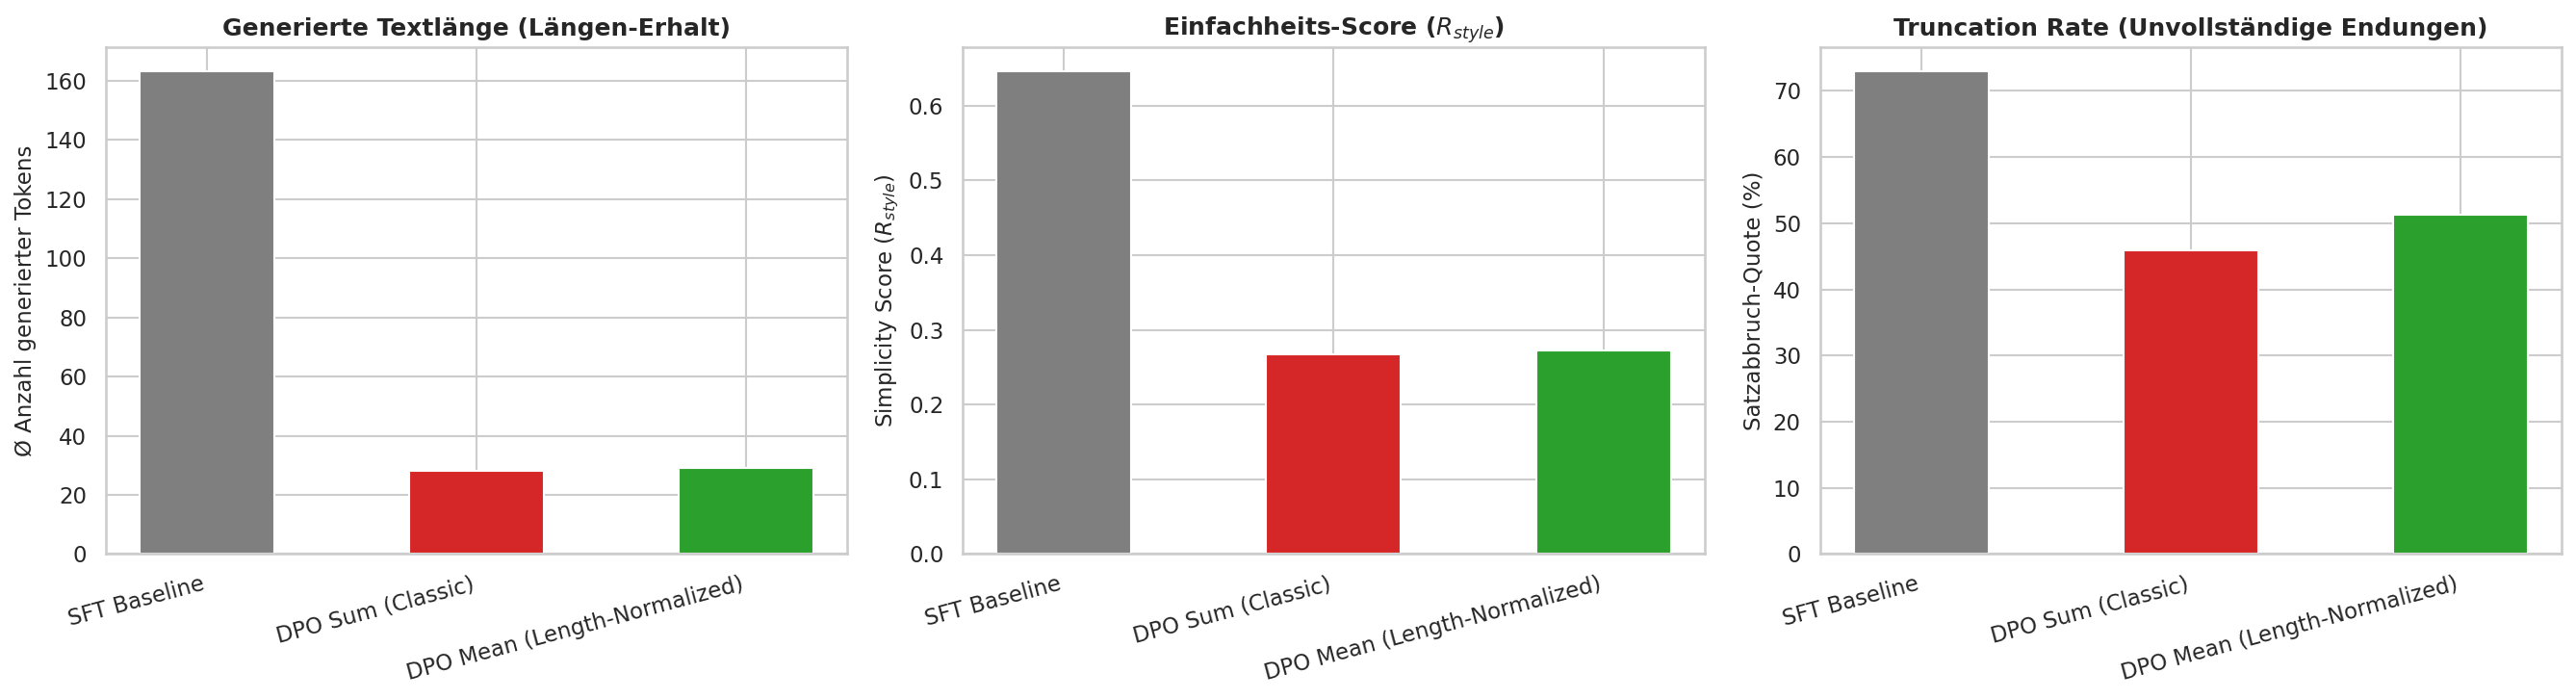

In [7]:
# ==============================================================================
# 7. KERNVERGLEICH: TOKEN-LAENGE & TRUNCATION RATE (SUM VS. MEAN)
# ==============================================================================
if 'df_summary' in locals() and len(df_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    name_col = [c for c in df_summary.columns if "Modell" in c or "model" in c][0]
    models = df_summary[name_col]
    x = np.arange(len(models))
    
    # 1. Generierte Token-Länge
    tok_col = [c for c in df_summary.columns if "Tokens" in c or "avg_gen_tokens" in c][0]
    axes[0].bar(x, df_summary[tok_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=15, ha="right")
    axes[0].set_ylabel("Ø Anzahl generierter Tokens", fontsize=11)
    axes[0].set_title("Generierte Textlänge (Längen-Erhalt)", fontsize=12, fontweight="bold")
    
    # 2. Simplicity Score
    simp_col = [c for c in df_summary.columns if "Simplicity" in c or "r_style" in c][0]
    axes[1].bar(x, df_summary[simp_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models, rotation=15, ha="right")
    axes[1].set_ylabel("Simplicity Score ($R_{style}$)", fontsize=11)
    axes[1].set_title("Einfachheits-Score ($R_{style}$)", fontsize=12, fontweight="bold")
    
    # 3. Truncation Rate (%)
    trunc_col = [c for c in df_summary.columns if "Truncation" in c or "truncation" in c][0]
    axes[2].bar(x, df_summary[trunc_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(models, rotation=15, ha="right")
    axes[2].set_ylabel("Satzabbruch-Quote (%)", fontsize=11)
    axes[2].set_title("Truncation Rate (Unvollständige Endungen)", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("results/plots/loss_aggregation_length_comparison.png", dpi=300)
    plt.show()
else:
    print("Keine Zusammenfassungsdaten fuer Plots vorhanden.")

## 6. Qualitativer Side-by-Side Modellvergleich (Beispielsätze)

In [8]:
# ==============================================================================
# 8. QUALITATIVES AUDIT: STICHPROBEN IM DETAIL
# ==============================================================================
if 'df_details' in locals() and len(df_details) > 0:
    sample_queries = df_details["as_text"].unique()[:4]
    
    for idx, as_s in enumerate(sample_queries, 1):
        sub_df = df_details[df_details["as_text"] == as_s]
        ls_ref = sub_df["ls_ref_text"].iloc[0]
        
        print(f"\n{'#'*90}")
        print(f"BEISPIEL {idx}:")
        print(f"[AS Quelle] : {as_s}")
        print(f"[LS Referenz]: {ls_ref}")
        print(f"{'-'*90}")
        
        for _, r in sub_df.iterrows():
            print(f"[{r['model_name']:30s}] (Simp: {r['r_style']:.3f} | Sem-AS: {r['r_sem_as']:.3f} | Tokens: {r['gen_tokens']}):")
            print(f"  {r['generated_text']}\n")
else:
    print("Keine Detail-Uebersetzungen verfuegbar.")


##########################################################################################
BEISPIEL 1:
[AS Quelle] : Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf dieser Basis ein selbstfinanziertes Leben führen zu können. Das bedeutet, dass die Menschen grundsätzlich Grundsicherung beantragen müssen, um ihren Lebensunterhalt zu bestreiten – es sei denn, sie erhalten bereits eine Erwerbsminderungsrente und können in der Werkstatt noch so viel dazu verdienen, dass es gerade zum Leben reicht. Die Pandemie-bedingten Betretungsverbote für die WfbMs und die damit aller Orten eingebrochenen Erträge machen die Auszahlung dieser Löhne nun aber auch immer schwieriger

## 7. Interaktiver Playground

In [9]:
# ==============================================================================
# 9. INTERAKTIVE LIVE-UEBERSETZUNG (EIGENER SATZ)
# ==============================================================================
def translate_custom_sentence(sentence: str):
    print(f"\n{'='*80}")
    print(f"Eingegebener Quelltext (AS):\n'{sentence}'")
    print(f"{'='*80}")
    
    for model_name, model_info in MODELS_CONFIG.items():
        m_path = model_info["path"]
        if not os.path.exists(m_path):
            continue
            
        tok_path = m_path if os.path.exists(os.path.join(m_path, "tokenizer_config.json")) else BASE_MODEL_NAME
        tokenizer = AutoTokenizer.from_pretrained(tok_path, use_fast=False)
        tokenizer.src_lang = "de_DE"
        tokenizer.tgt_lang = "de_DE"
        
        model = load_seq2seq_model(m_path, BASE_MODEL_NAME)
        model.eval()
        
        inputs = tokenizer([sentence], max_length=MAX_SOURCE_LEN, padding=True, truncation=True, return_tensors="pt").to(DEVICE)
        with torch.no_grad():
            out = model.generate(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], max_length=MAX_TARGET_LEN, num_beams=4, no_repeat_ngram_size=3)
        trans = tokenizer.decode(out[0], skip_special_tokens=True)
        
        simp = float(compute_simplicity_scores([trans])[0])
        sem = float(np.clip((compute_semantic_similarity([sentence], [trans])[0] + 1.0) / 2.0, 0.0, 1.0))
        
        print(f"\n[{model_name}] (Simplicity: {simp:.3f}, Semantik: {sem:.3f}):")
        print(f"  {trans}")
        
        del model
        torch.cuda.empty_cache()

test_input = "Die Bundesregierung hat ein umfassendes Maßnahmenpaket zur Entlastung von Familien und Pflegebedürftigen beschlossen."
translate_custom_sentence(test_input)


Eingegebener Quelltext (AS):
'Die Bundesregierung hat ein umfassendes Maßnahmenpaket zur Entlastung von Familien und Pflegebedürftigen beschlossen.'


TypeError: PeftModelForSeq2SeqLM.generate() takes 1 positional argument but 2 were given